Fetched 89 txrefs for 1BoatSLRHtKNngkdXEeobR76b53LETtpyT
Clusters detected:
{'bc1pws6pvj75rcsc2eglpp9k570prnjh40nfpyahlyumk8y8smjayvasyhns5c', '1BoatSLRHtKNngkdXEeobR76b53LETtpyT'}


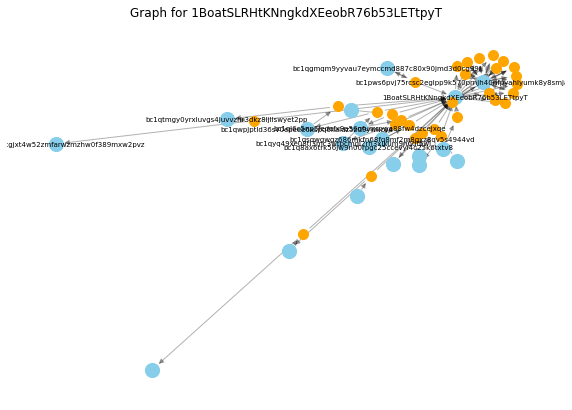

In [2]:
import requests
import networkx as nx
import matplotlib.pyplot as plt
import time

SEED_ADDRESS = "1BoatSLRHtKNngkdXEeobR76b53LETtpyT"  # Example
API_BASE = "https://api.blockcypher.com/v1/btc/main"
BLOCKCYPHER_TOKEN = None  # optional

def _get(url, params=None, max_retries=3, backoff=1.0):
    params = params or {}
    for attempt in range(1, max_retries+1):
        try:
            r = requests.get(url, params=params, timeout=20)
            return r
        except requests.RequestException as e:
            if attempt == max_retries:
                raise
            time.sleep(backoff * attempt)

def fetch_transactions(address, limit=50, try_full_if_empty=True, token=None):
    params = {"limit": limit}
    if token:
        params["token"] = token

    url = f"{API_BASE}/addrs/{address}/full"
    r = _get(url, params=params)
    #print(f"r detected: {r}")
    if r.status_code != 200:
        raise RuntimeError(f"BlockCypher error {r.status_code}: {r.text}")

    data = r.json()
    #print(f"r detected: {data}")
    txs = data.get("txs", [])
    #print(f"txs detected: {txs}")
    normalized = []
    for tx in txs:
        txid = tx.get("hash")
        #print(f"Fetched {txid} txid for {SEED_ADDRESS}")
        # inputs
        for vin in tx.get("inputs", []):
            for a in vin.get("addresses", []) or []:
                if a:  # skip None
                    normalized.append({
                        "tx_hash": txid,
                        "address": a,
                        "tx_output_n": -1,
                        "value": vin.get("output_value", 0)
                    })
                    #print(f"Normalized {normalized}")
        # outputs
        for idx, vout in enumerate(tx.get("outputs", [])):
            for a in vout.get("addresses", []) or []:
                if a:  # skip None
                    normalized.append({
                        "tx_hash": txid,
                        "address": a,
                        "tx_output_n": idx,
                        "value": vout.get("value", 0)
                    })
    #print(f"Normalized {normalized}")                
    return normalized

def build_graph(txrefs):
    G = nx.DiGraph()
    for tx in txrefs:
        txid = tx["tx_hash"]
        addr = tx["address"]
        if not addr:  # skip None addresses
            continue
        val = tx.get("value", 0)

        G.add_node(txid, type="tx")
        G.add_node(addr, type="addr")

        if tx.get("tx_output_n", 0) >= 0:
            G.add_edge(txid, addr, kind="output", value=val)
        else:
            G.add_edge(addr, txid, kind="input", value=val)
    return G

def common_input_clusters(txrefs):
    cluster_graph = nx.Graph()
    tx_inputs = {}
    for tx in txrefs:
        addr = tx["address"]
        if not addr:  # skip None
            continue
        if tx.get("tx_output_n", 0) < 0:
            txid = tx["tx_hash"]
            tx_inputs.setdefault(txid, []).append(addr)
    for addrs in tx_inputs.values():
        for i in range(len(addrs)):
            for j in range(i + 1, len(addrs)):
                cluster_graph.add_edge(addrs[i], addrs[j])
    return list(nx.connected_components(cluster_graph))

# -----------------------------
# Run
# -----------------------------
txrefs = fetch_transactions(SEED_ADDRESS, limit=30)
#print(f"Fetched {txrefs} txrefs for {SEED_ADDRESS}")
print(f"Fetched {len(txrefs)} txrefs for {SEED_ADDRESS}")

G = build_graph(txrefs)
clusters = common_input_clusters(txrefs)

print("Clusters detected:")
for c in clusters:
    print(c)

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, seed=42)
addr_nodes = [n for n,d in G.nodes(data=True) if d.get("type")=="addr"]
tx_nodes = [n for n,d in G.nodes(data=True) if d.get("type")=="tx"]
nx.draw_networkx_nodes(G, pos, nodelist=addr_nodes, node_size=200, node_color="skyblue")
nx.draw_networkx_nodes(G, pos, nodelist=tx_nodes, node_size=100, node_color="orange")
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, labels={n:n for n in addr_nodes[:10]}, font_size=7)
plt.title(f"Graph for {SEED_ADDRESS}")
plt.axis("off")
plt.savefig("suspicious_flow10.png", dpi=300, bbox_inches="tight")
plt.show()
